# What-if: 랜드마크 미선택(사람만) → GAIC top3

**세션 `20260712_072917_201`** 은 실제로 targets에 **person + homigot_hand(랜드마크)** 를 선택해서
`/capture`가 **DINO 분기**(clip_dino)로 best 크롭을 골랐다 (report.json: `best.source_box_in_1x=[176,0,1205,771]`, sim≈0.88).

**가정**: 만약 **랜드마크(homigot_hand)를 선택 안 하고 사람만** 선택했다면 → `/capture`는 **GAIC 분기**로 갔을 것.
그때 **48분할 후보 중 GAIC 상위 3개가 무엇이고 점수가 몇이었을지**를 실제 파이프라인 함수로 재현해 구한다.

- 재사용: `services.crop_candidates.generate_candidates` / `filter_candidates_by_boxes`, `models.gaic.score_boxes`
- best_crop과 동일 파라미터: zoom_ratio=1.4, 8×6=48분할, contain_thres=0.90, fallback_topk=12
- 필터에 **사람 박스만** 넣는다(랜드마크 박스 제외) → 이게 "사람만 선택" 시나리오.

In [1]:
# ── 셋업 ─────────────────────────────────────────────────────────
import os, sys, io, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path(os.getcwd())
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "main.py").exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT); sys.path.insert(0, str(REPO_ROOT))
try:
    plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception: pass

SID = "20260712_072917_201"
ORIG = REPO_ROOT / "drone-data" / SID / "1_original"
report = json.loads((ORIG / "report.json").read_text(encoding="utf-8"))
img_1x = Image.open(ORIG / "original_1x.jpg").convert("RGB")
img_2x = Image.open(ORIG / "original_1_5x.jpg").convert("RGB")   # 1.4배 확대본(후보 출력 크기 기준)
W, H = img_1x.size
print("session:", SID, "| 원본 크기:", (W, H))
print("targets:", [(t["class"], t["bbox"]) for t in report["targets"]])
print("실제 DINO best box:", report["best"]["source_box_in_1x"], "| sim:", round(report["best"]["similarity"], 4))

session: 20260712_072917_201 | 원본 크기: (1440, 1080)
targets: [('person', [0.5616000294685364, 0.45730000734329224, 0.0997999981045723, 0.30399999022483826]), ('homigot_hand', [0.5044000148773193, 0.35839998722076416, 0.08349999785423279, 0.19040000438690186])]
실제 DINO best box: [176, 0, 1205, 771] | sim: 0.8797


## 1. 사람 박스만 뽑기 (랜드마크 제외 = 사람만 선택 시나리오)
report.json의 `results`에서 **class=='person'** 인 것의 픽셀 박스만 필터 입력으로 쓴다.

In [2]:
# ── 사람 박스만 (필터 입력) ──────────────────────────────────────
person_boxes = []
for r in report.get("results", []):
    if str(r.get("class", "")).lower() == "person":
        bp = r["bbox_pixel"]
        person_boxes.append({"class": "person", "box": [bp["left"], bp["top"], bp["right"], bp["bottom"]]})
print("사람 박스 개수:", len(person_boxes))
for b in person_boxes: print("  ", b)

사람 박스 개수: 1
   {'class': 'person', 'box': [736, 329, 880, 658]}


## 2. 48분할 후보 생성 + 사람 박스로 잘림 필터
best_crop과 동일: `generate_candidates`(zoom 1.4, 8×6) → `filter_candidates_by_boxes`(person 박스, 0.90, fallback 12).

In [3]:
# ── 후보 생성 + 필터 ─────────────────────────────────────────────
from services.crop_candidates import generate_candidates, filter_candidates_by_boxes

candidates = generate_candidates(img_1x=img_1x, img_2x_size=img_2x.size, zoom_ratio=1.4, cols=8, rows=6)
filtered, status = filter_candidates_by_boxes(
    candidates=candidates, boxes=person_boxes,
    contain_thres=0.90, edge_margin_ratio=0.0, selected_require="all", fallback_topk=12,
)
print(f"48분할 후보 {len(candidates)}개 → 사람 잘림 필터 통과 {len(filtered)}개 (status={status})")

[INFO] candidate window: 1x=1440x1080, window=1029x771, output=1440x1080, grid=8x6
[INFO] coordinate filter top candidates:
  candidate00: coord_score=1.0000, source_box=(0, 0, 1029, 771)
  candidate01: coord_score=1.0000, source_box=(59, 0, 1088, 771)
  candidate02: coord_score=1.0000, source_box=(117, 0, 1146, 771)
  candidate03: coord_score=1.0000, source_box=(176, 0, 1205, 771)
  candidate04: coord_score=1.0000, source_box=(235, 0, 1264, 771)
  candidate05: coord_score=1.0000, source_box=(294, 0, 1323, 771)
  candidate06: coord_score=1.0000, source_box=(352, 0, 1381, 771)
  candidate07: coord_score=1.0000, source_box=(411, 0, 1440, 771)
  candidate08: coord_score=1.0000, source_box=(0, 62, 1029, 833)
  candidate09: coord_score=1.0000, source_box=(59, 62, 1088, 833)
[INFO] coordinate filter: 48 -> 48 (strict)
48분할 후보 48개 → 사람 잘림 필터 통과 48개 (status=strict)


## 3. GAIC로 채점 → **상위 3개 + 점수** (핵심 답)

In [4]:
# ── GAIC 채점 → top3 ─────────────────────────────────────────────
from models import gaic

scores = gaic.score_boxes(img_1x, [c.source_box for c in filtered])
rows = [{"candidate_index": c.index, "source_box": list(c.source_box), "gaic_score": round(float(s), 4)}
        for c, s in zip(filtered, scores)]
df = pd.DataFrame(rows).sort_values("gaic_score", ascending=False).reset_index(drop=True)
df.insert(0, "rank", df.index + 1)

print("=== GAIC 상위 3개 (사람만 선택 시나리오) ===")
top3 = df.head(3)
display(top3)
print("\n(전체 통과 후보 점수 분포)")
df

[gaic] loading mobilenetv2 on cpu (/Users/yujin/Desktop/Yujin/포빅아/B2조_AI_프로젝트/photo-director-engine/models/gaic_bundle/pretrained_models/GAIC-mobilenetv2-reddim16.pth)
=== GAIC 상위 3개 (사람만 선택 시나리오) ===


,rank,candidate_index,source_box,gaic_score
0,1,10,"[117, 62, 1146, 833]",4.3944
1,2,18,"[117, 124, 1146, 895]",4.2289
2,3,2,"[117, 0, 1146, 771]",3.9980



(전체 통과 후보 점수 분포)


,rank,candidate_index,source_box,gaic_score
0,1,10,"[117, 62, 1146, 833]",4.3944
1,2,18,"[117, 124, 1146, 895]",4.2289
2,3,2,"[117, 0, 1146, 771]",3.9980
3,4,26,"[117, 185, 1146, 956]",3.9417
4,5,9,"[59, 62, 1088, 833]",3.7909
5,6,11,"[176, 62, 1205, 833]",3.7743
6,7,17,"[59, 124, 1088, 895]",3.7409
7,8,19,"[176, 124, 1205, 895]",3.7339
8,9,15,"[411, 62, 1440, 833]",3.6218
9,10,27,"[176, 185, 1205, 956]",3.5927


## 4. 상위 3개 크롭 이미지

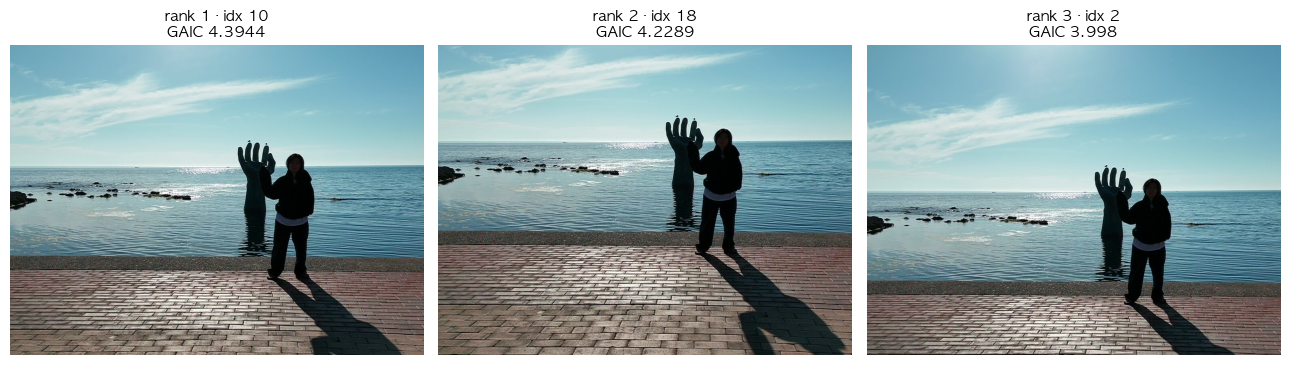

In [5]:
# ── top3 크롭 썸네일 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, (_, r) in zip(axes, top3.iterrows()):
    ax.imshow(img_1x.crop(tuple(int(v) for v in r["source_box"])))
    ax.set_title(f"rank {int(r['rank'])} · idx {int(r['candidate_index'])}\nGAIC {r['gaic_score']}", fontsize=11)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. 원본 위 오버레이 — GAIC top3(초록) vs 실제 DINO best(빨강)
"사람만 선택했으면 어디를 골랐을지"(GAIC)와 "실제 랜드마크 포함해 고른 것"(DINO)을 비교.

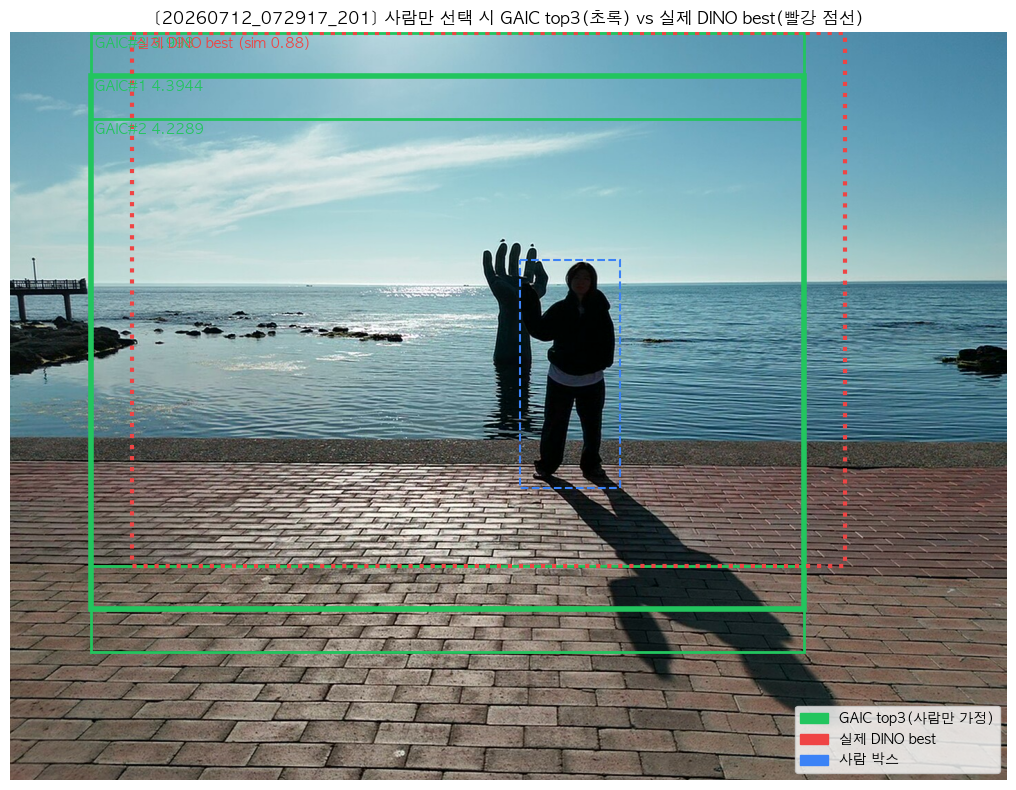

In [6]:
# ── 오버레이 ─────────────────────────────────────────────────────
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(img_1x)
# 사람 박스(참고, 파랑 점선)
for b in person_boxes:
    x1, y1, x2, y2 = b["box"]
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#3b82f6", lw=1.5, ls="--"))
# GAIC top3 (초록, 굵기/투명도로 순위)
for _, r in top3.iterrows():
    x1, y1, x2, y2 = r["source_box"]
    lw = 4 if r["rank"] == 1 else 2
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="#22c55e", lw=lw))
    ax.text(x1 + 5, y1 + 22, f"GAIC#{int(r['rank'])} {r['gaic_score']}", color="#22c55e", fontsize=10, weight="bold")
# 실제 DINO best (빨강)
dx1, dy1, dx2, dy2 = report["best"]["source_box_in_1x"]
ax.add_patch(plt.Rectangle((dx1, dy1), dx2 - dx1, dy2 - dy1, fill=False, edgecolor="#ef4444", lw=3, ls=":"))
ax.text(dx1 + 5, dy1 + 22, f"실제 DINO best (sim {round(report['best']['similarity'],3)})", color="#ef4444", fontsize=10, weight="bold")
ax.set_title(f"[{SID}] 사람만 선택 시 GAIC top3(초록) vs 실제 DINO best(빨강 점선)")
ax.legend(handles=[mpatches.Patch(color="#22c55e", label="GAIC top3(사람만 가정)"),
                   mpatches.Patch(color="#ef4444", label="실제 DINO best"),
                   mpatches.Patch(color="#3b82f6", label="사람 박스")], loc="lower right")
ax.axis("off"); plt.tight_layout(); plt.show()

## 정리
- 위 **표(top3)** 가 "랜드마크 미선택·사람만 선택" 시 GAIC가 골랐을 **상위 3개 후보와 점수**다.
- rank 1이 그 시나리오의 최종 best가 된다(실제로는 랜드마크를 넣어 DINO가 다른 걸 골랐음 — 오버레이로 차이 확인).
- 파라미터/함수는 실제 `/capture` GAIC 분기와 동일(`generate_candidates`·`filter_candidates_by_boxes`·`gaic.score_boxes`).